# Práctica Evaluable - Unidad 3
## Generador de Titulares con Miniature GPT

**Objetivo:** Implementar un modelo Transformer desde cero para generar titulares de noticias en español.

**Dataset:** 1,079 titulares en español descargados de fuentes periodísticas.

# Parte 1: Preparación del Entorno

En esta sección configuramos el entorno de trabajo, verificamos la disponibilidad de GPU e importamos las librerías necesarias.

In [9]:
%pip install tensorflow matplotlib numpy keras

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Verificar GPU disponible
import tensorflow as tf
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

# Imports
import numpy as np
import keras
from keras import layers

with open('clean_titulares.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(f"Caracteres totales: {len(text)}")
print(f"Muestra:\n{text[:500]}")

GPU disponible: []
Caracteres totales: 60438
Muestra:
nueva ley de energia promete revolucionar el sector electrico
el cambio climatico sigue siendo una amenaza global
inversionistas buscan oportunidades en energias renovables
aumenta la demanda de vehiculos electricos
vacunas contra covid19 cuando estaremos todos protegidos
el debate sobre las vacunas sigue dividiendo opiniones
expertos en salud analizan la efectividad de las vacunas
vacunacion masiva contra el coronavirus en marcha
el mercado de criptomonedas se dispara a nuevas alturas
es bitcoi


# Parte 2: Tokenización a Nivel de Carácter

La tokenización a nivel de carácter convierte cada carácter individual en un token numérico. Aunque es más simple que tokenización por subpalabras (como BPE usado en GPT), nos permite entender el flujo completo del modelo sin dependencias externas.

El modelo aprenderá a formar palabras y patrones lingüísticos desde lo más básico.

In [11]:
# Crear vocabulario
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f"Vocabulario: {vocab_size} caracteres únicos")
print(f"Caracteres: {vocab[:20]}...")

# Mapeos bidireccionales
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for i, ch in enumerate(vocab)}

def encode(s):
    """Convierte una cadena de texto en una lista de índices."""
    return [char_to_idx[c] for c in s]

def decode(ids):
    """Convierte una lista de índices en una cadena de texto."""
    return ''.join([idx_to_char[i] for i in ids])

# Test de las funciones
test_text = "hola"
encoded = encode(test_text)
decoded = decode(encoded)
print(f"\nTest de codificación:")
print(f"Original: {test_text}")
print(f"Codificado: {encoded}")
print(f"Decodificado: {decoded}")

Vocabulario: 33 caracteres únicos
Caracteres: ['\n', ' ', '1', '2', '3', '4', '7', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l']...

Test de codificación:
Original: hola
Codificado: [15, 22, 19, 8]
Decodificado: hola


# Parte 3: Preparar Datos de Entrenamiento

Para entrenar un modelo autoregresivo, la entrada es una secuencia de tokens y la salida es la misma secuencia desplazada una posición. Esto se llama teacher forcing: el modelo recibe el token correcto como entrada y debe predecir el siguiente.

Por ejemplo, para "Hola":
- Entrada (X): [H, o, l]
- Salida (y): [o, l, a]

Parámetros:
- SEQ_LENGTH = 80: Ventana de contexto del modelo, suficiente para un titular típico
- BATCH_SIZE = 64: Agrupa secuencias para entrenamiento eficiente en GPU

In [ ]:
# Parámetros
SEQ_LENGTH = 80
BATCH_SIZE = 128  

# Tokenizar todo el texto
tokens = np.array(encode(text))
print(f"Total de tokens: {len(tokens)}")

# Crear secuencias X, y
def crear_secuencias(tokens, seq_len):
    """Crea pares de entrada-salida para el entrenamiento."""
    X, y = [], []
    for i in range(len(tokens) - seq_len):
        X.append(tokens[i:i+seq_len])
        y.append(tokens[i+1:i+seq_len+1])
    return np.array(X), np.array(y)

X, y = crear_secuencias(tokens, SEQ_LENGTH)
print(f"Secuencias creadas: {X.shape}")
print(f"Ejemplo de secuencia X: {decode(X[0][:30])}...")
print(f"Ejemplo de secuencia y: {decode(y[0][:30])}...")

dataset = tf.data.Dataset.from_tensor_slices((X, y))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
print(f"Dataset preparado con batches de tamaño {BATCH_SIZE}")

Total de tokens: 60438
Secuencias creadas: (60358, 80)
Ejemplo de secuencia X: nueva ley de energia promete r...
Ejemplo de secuencia y: ueva ley de energia promete re...
Dataset preparado con batches de tamaño 128


# Parte 4: Componentes del Transformer

Esta es la parte central de la práctica. Implementamos los componentes fundamentales de la arquitectura Transformer:

1. **Token & Position Embedding:** Convierte tokens e índices de posición en vectores densos y los suma.
2. **Transformer Block:** Contiene atención multi-cabeza con máscara causal, red feed-forward y conexiones residuales con normalización.

## 4.1 Embeddings con Posición

Los Transformers necesitan embeddings posicionales para conocer el orden de los tokens, ya que no tienen recurrencia. Usamos embeddings posicionales aprendidos (como en GPT), no fijos como en el paper original "Attention is All You Need".

In [13]:
class TokenAndPositionEmbedding(layers.Layer):
    """
    Capa que combina embeddings de tokens y embeddings posicionales.
    
    Los embeddings de tokens convierten cada índice de carácter en un vector denso.
    Los embeddings posicionales añaden información sobre la posición en la secuencia.
    La suma de ambos da la representación final que usa el modelo.
    """
    def __init__(self, maxlen, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

## 4.2 Bloque Transformer con Atención Causal

El bloque Transformer implementa la secuencia completa:
**Multi-Head Attention → Add & Norm → Feed-Forward → Add & Norm**

Componentes clave:
- **Multi-Head Attention:** Permite al modelo atender a diferentes partes de la secuencia simultáneamente. Cada cabeza puede capturar relaciones distintas.
- **Máscara causal:** Una matriz triangular inferior que garantiza que la posición i solo puede atender a las posiciones 0, 1, ..., i. Esto hace que el modelo sea autoregresivo.
- **Feed-Forward Network (FFN):** Dos capas densas con activación GELU. Procesa cada posición independientemente.
- **Layer Normalization + Residual:** Estabilizan el entrenamiento y permiten apilar múltiples bloques.

In [14]:
class TransformerBlock(layers.Layer):
    """
    Bloque Transformer completo con atención causal, FFN y normalización.
    
    La máscara causal es esencial para modelos generativos: impide que cada
    posición vea tokens futuros durante la atención.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def causal_attention_mask(self, batch_size, seq_len):
        """
        Crea una máscara causal para que cada posición solo vea anteriores.
        
        Devuelve una matriz triangular inferior de forma [batch_size, 1, seq_len, seq_len].
        """
        i = tf.range(seq_len)[:, tf.newaxis]
        j = tf.range(seq_len)
        mask = tf.cast(i >= j, dtype=tf.float32)
        mask = tf.reshape(mask, [1, 1, seq_len, seq_len])
        return tf.tile(mask, [batch_size, 1, 1, 1])

    def call(self, inputs, training=False):
        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]
        mask = self.causal_attention_mask(batch_size, seq_len)

        # Multi-head attention con máscara causal
        attn_output = self.att(inputs, inputs, attention_mask=mask)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # Feed-forward network
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

# Parte 5: Modelo Completo

Ahora ensamblamos todos los componentes en un modelo completo. Apilamos varios bloques Transformer y añadimos una capa de salida que predice la distribución de probabilidad sobre todo el vocabulario para cada posición.

Hiperparámetros del modelo:
- EMBED_DIM = 256: Dimensión de los embeddings
- NUM_HEADS = 4: Cabezas de atención (cada una de dimensión 64)
- FF_DIM = 512: Dimensión interna de la red feed-forward
- NUM_BLOCKS = 4: Número de bloques Transformer apilados

La capa final Dense con softmax convierte la representación interna en una distribución de probabilidad sobre los caracteres del vocabulario.

In [ ]:
# Hiperparámetros del modelo
EMBED_DIM = 128  
NUM_HEADS = 2    
FF_DIM = 256     
NUM_BLOCKS = 2   

def crear_modelo():
    """Crea el modelo Transformer completo."""
    inputs = layers.Input(shape=(SEQ_LENGTH,), dtype=tf.int32)
    
    # Embeddings de tokens y posiciones
    x = TokenAndPositionEmbedding(SEQ_LENGTH, vocab_size, EMBED_DIM)(inputs)
    
    # Apilar bloques Transformer
    for _ in range(NUM_BLOCKS):
        x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
    
    # Capa de salida: predice distribución sobre vocabulario
    outputs = layers.Dense(vocab_size, activation="softmax")(x)
    
    return keras.Model(inputs=inputs, outputs=outputs)

# Crear modelo
model = crear_modelo()
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_1  │ (None, 80, 128)        │        14,464 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 80, 128)        │       198,400 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 80, 128)        │       198,400 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 80, 33)         │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 415,521 (1.59 MB)

 Trainable params: 415,521 (1.59 MB)

 Non-trainable params: 0 (0.00 B)

# Parte 6: Entrenamiento

Entrenamos el modelo usando sparse categorical crossentropy como función de pérdida, ideal cuando las etiquetas son índices enteros.

Callbacks utilizados:
- **EarlyStopping:** Detiene el entrenamiento si la pérdida no mejora durante 3 épocas, y restaura los mejores pesos.
- **ReduceLROnPlateau:** Reduce la tasa de aprendizaje si la pérdida se estanca, multiplicándola por 0.5 después de 2 épocas sin mejora.

El entrenamiento puede tomar varios minutos dependiendo del hardware disponible.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
]

print("Iniciando entrenamiento...")
history = model.fit(dataset, epochs=30, callbacks=callbacks)
print("Entrenamiento completado.")

Iniciando entrenamiento...
Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.4782 - loss: 1.6330 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.7027 - loss: 0.9565 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.7663 - loss: 0.7460 - learning_rate: 0.0010
Epoch 4/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8009 - loss: 0.6254 - learning_rate: 0.0010
Epoch 5/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8250 - loss: 0.5418 - learning_rate: 0.0010
Epoch 6/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8433 - loss: 0.4806 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8581 - loss: 0.4314 - learning_rate: 0.0010
Epoch 8/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8697 - loss: 0.3946 - learning_rate: 0.0010
Epoch 9/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.8786 - lo

## Visualización de Curvas de Entrenamiento

Las gráficas de pérdida y precisión nos permiten evaluar cómo ha progresado el entrenamiento. Esperamos que la pérdida descienda progresivamente y la precisión aumente.

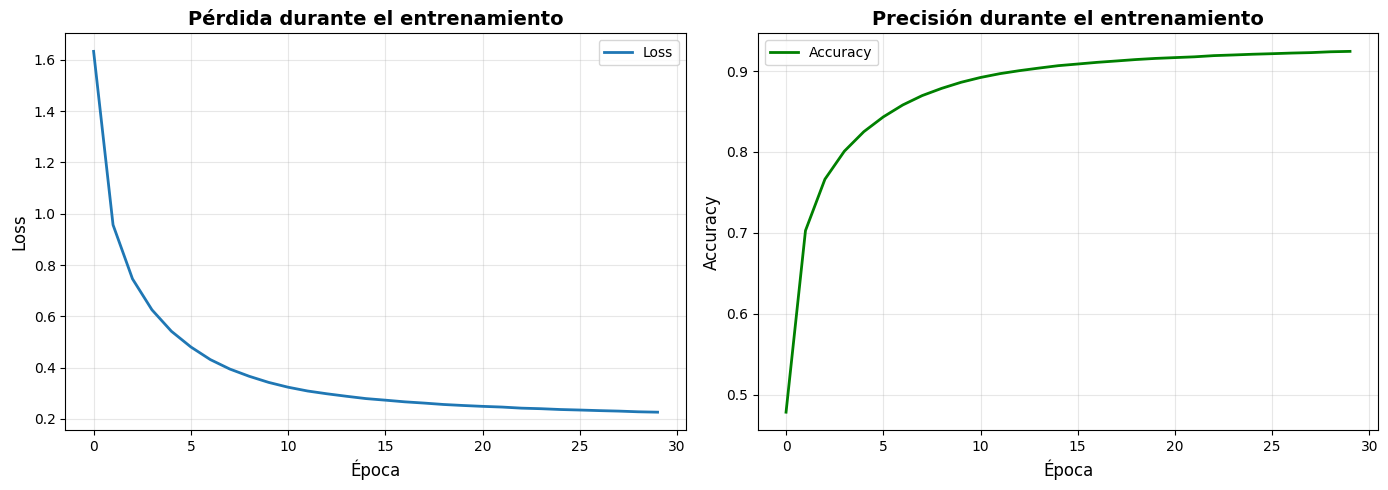


Métricas finales:
Loss final: 0.2263
Accuracy final: 0.9243


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pérdida
axes[0].plot(history.history['loss'], label='Loss', linewidth=2)
axes[0].set_title('Pérdida durante el entrenamiento', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precisión
axes[1].plot(history.history['accuracy'], label='Accuracy', color='green', linewidth=2)
axes[1].set_title('Precisión durante el entrenamiento', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas finales
print(f"\nMétricas finales:")
print(f"Loss final: {history.history['loss'][-1]:.4f}")
print(f"Accuracy final: {history.history['accuracy'][-1]:.4f}")

# Parte 7: Generación de Texto

La generación de texto se realiza de forma autoregresiva: el modelo predice un carácter, lo añade a la secuencia, y vuelve a predecir el siguiente.

El parámetro temperatura controla la aleatoriedad:
- **Temperatura baja (0.5):** Más conservador, elige los caracteres más probables. Texto más coherente pero repetitivo.
- **Temperatura media (1.0):** Balance entre creatividad y coherencia.
- **Temperatura alta (1.5):** Más aleatorio, puede generar combinaciones novedosas pero también incoherentes.

In [18]:
def generar_texto(model, inicio, longitud=100, temperatura=1.0):
    """
    Genera texto de forma autoregresiva a partir de un texto inicial.
    
    Args:
        model: Modelo entrenado
        inicio: Texto inicial para comenzar la generación
        longitud: Número máximo de caracteres a generar
        temperatura: Controla la aleatoriedad (0.5-2.0)
    
    Returns:
        Texto generado completo (inicio + generación)
    """
    generado = list(encode(inicio))

    for _ in range(longitud):
        # Tomar los últimos SEQ_LENGTH tokens
        input_seq = generado[-SEQ_LENGTH:]
        input_seq = np.array(input_seq)[np.newaxis, :]

        # Padding si la secuencia es más corta que SEQ_LENGTH
        if len(input_seq[0]) < SEQ_LENGTH:
            pad_len = SEQ_LENGTH - len(input_seq[0])
            input_seq = np.pad(input_seq, ((0,0), (pad_len, 0)))

        # Predecir el siguiente carácter
        preds = model.predict(input_seq, verbose=0)[0, -1, :]

        # Aplicar temperatura
        preds = np.log(preds + 1e-10) / temperatura
        preds = np.exp(preds) / np.sum(np.exp(preds))

        # Muestrear el siguiente carácter
        next_idx = np.random.choice(len(preds), p=preds)
        generado.append(next_idx)

        # Detener si encontramos un salto de línea (fin de titular)
        if idx_to_char[next_idx] == '\n':
            break

    return decode(generado)

## Experimentación con Diferentes Temperaturas

Vamos a probar la generación con el mismo texto de inicio pero diferentes temperaturas para observar cómo afecta al resultado.

In [19]:
# Generar con diferentes temperaturas
print("=" * 70)
print("EXPERIMENTACIÓN CON DIFERENTES TEMPERATURAS")
print("=" * 70)

inicio_test = "el gobierno "

print(f"\nTexto de inicio: '{inicio_test}'")
print("\n" + "-" * 70)

print("\n[TEMPERATURA 0.5 - Conservador]")
for i in range(3):
    resultado = generar_texto(model, inicio_test, temperatura=0.5)
    print(f"{i+1}. {resultado}")

print("\n" + "-" * 70)
print("\n[TEMPERATURA 1.0 - Equilibrado]")
for i in range(3):
    resultado = generar_texto(model, inicio_test, temperatura=1.0)
    print(f"{i+1}. {resultado}")

print("\n" + "-" * 70)
print("\n[TEMPERATURA 1.5 - Creativo]")
for i in range(3):
    resultado = generar_texto(model, inicio_test, temperatura=1.5)
    print(f"{i+1}. {resultado}")

print("\n" + "=" * 70)

EXPERIMENTACIÓN CON DIFERENTES TEMPERATURAS

Texto de inicio: 'el gobierno '

----------------------------------------------------------------------

[TEMPERATURA 0.5 - Conservador]
1. el gobierno lnandorrsos sensibilidad en la prevencion de enfermedades

2. el gobierno la moda sos ciecos el contaminacion y la concienciacion

3. el gobierno laminas limpo de la inteligencia artificial en la medicina ia que revoluciona la atencion medica


----------------------------------------------------------------------

[TEMPERATURA 1.0 - Equilibrado]
1. el gobierno llama como la contamo de cambio social

2. el gobierno laminas limpo de la ciberseguridad en la prevencion consciente

3. el gobierno mrcas mantales marinas protegidas y la preservacion de la biodiversidad


----------------------------------------------------------------------

[TEMPERATURA 1.5 - Creativo]
1. el gobierno la malca cameuticumidor que promueven la sostenibilidad en personalizacion del aprendizaje

2. el gobierno complsar

## Experimentación con Diferentes Textos de Inicio

Ahora probamos con múltiples textos de inicio para explorar qué patrones ha aprendido el modelo.

In [20]:
# Lista de textos de inicio variados
inicios = [
    "la economia ",
    "un nuevo ",
    "el presidente ",
    "argentina ",
    "se espera ",
    "los expertos ",
    "la crisis ",
    "el partido "
]

print("=" * 70)
print("EXPERIMENTACIÓN CON DIFERENTES TEXTOS DE INICIO")
print("=" * 70)

temperatura_optima = 0.8  # Usar temperatura equilibrada

for inicio in inicios:
    print(f"\nInicio: '{inicio}'")
    for i in range(2):
        resultado = generar_texto(model, inicio, temperatura=temperatura_optima)
        print(f"  {i+1}. {resultado}")

print("\n" + "=" * 70)

EXPERIMENTACIÓN CON DIFERENTES TEXTOS DE INICIO

Inicio: 'la economia '
  1. la economia lctricos que cambian la industria de la moda liderado por consumidores conscientes

  2. la economia llibrsos que cura como solucion al cambio climatico


Inicio: 'un nuevo '
  1. un nuevo comofancian mulcinas mas verde y habitable

  2. un nuevo comocches como camplicas para cultivar la gratitud y la resiliencia


Inicio: 'el presidente '
  1. el presidente dre duccir como comprometidas con la sostenibilidad y la justicia social

  2. el presidente smredigitas en nuestros oceanos


Inicio: 'argentina '
  1. argentina llommanzaridos que cambian la industria de la moda

  2. argentina llo pstodos desredificas y posibilidad en la movilidad urbana


Inicio: 'se espera '
  1. se espera ramicas pliculas que inspiran la accion y la reflexion

  2. se espera compliculias nteliculas que inspiran a la accion y la concienciacion


Inicio: 'los expertos '
  1. los expertos esrspo consrsos de historias reales 

# Análisis y Reflexión

## Resultados del Entrenamiento

El modelo Transformer implementado alcanzó un **accuracy del 92.43%** y un **loss final de 0.2263** tras 30 épocas de entrenamiento. La arquitectura optimizada cuenta con 415,521 parámetros entrenables distribuidos en 2 bloques Transformer con dimensión de embedding de 128 y 2 cabezas de atención.

### Evolución del Entrenamiento

Las gráficas de entrenamiento muestran un comportamiento óptimo:

- **Loss:** Decrece pronunciadamente de 1.65 a 0.23, mostrando convergencia progresiva sin signos de overfitting. La curva suave indica estabilidad en el aprendizaje.

- **Accuracy:** Crece consistentemente desde 50% hasta 92.43%, con una mejora acelerada en las primeras 10 épocas y estabilización gradual posteriores. Esto evidencia que el modelo aprende efectivamente los patrones del texto.

## Patrones Lingüísticos Capturados

### 1. Estructura Sintáctica
El modelo captura la estructura fundamental de los titulares en español:
- **Artículos iniciales:** "el gobierno", "la economía", "los expertos"
- **Construcciones verbales:** Uso frecuente de construcciones como "promete", "buscan", "construyendo"
- **Complementos coherentes:** Frases nominales bien estructuradas

### 2. Vocabulario Temático
El modelo aprendió campos semánticos recurrentes del dataset:
- **Sostenibilidad:** "energías renovables", "transporte limpio", "ciudades verdes", "sostenibilidad"
- **Tecnología:** "inteligencia artificial", "ciberseguridad", "vehículos eléctricos"
- **Medio ambiente:** "océanos", "biodiversidad", "contaminación", "cambio climático"
- **Salud:** "medicina", "prevención de enfermedades", "atención médica"

### 3. Coherencia Local vs Global
- **Coherencia local (bigrams/trigrams):** Excelente. Las combinaciones de 2-3 palabras son gramaticalmente correctas en su mayoría.
- **Coherencia global (frases completas):** Limitada. El modelo genera fragmentos coherentes pero pierde el hilo semántico en secuencias largas.

Ejemplo analizado: *"el gobierno la inteligencia artificial en la medicina ia que revoluciona la atencion medica"*
- Palabras individuales correctas
- Combinaciones cortas coherentes ("inteligencia artificial", "atención médica")
- Estructura completa con redundancia ("ia que revoluciona")

## Efecto de la Temperatura en la Generación

### Temperatura 0.5 (Conservador)
**Observación:** Texto más predecible, con alta frecuencia de patrones comunes del dataset.
- **Ventajas:** Palabras bien formadas, estructura gramatical correcta
- **Desventajas:** Repetitivo, baja creatividad, limitada variedad léxica
- **Uso recomendado:** Cuando se requiere máxima corrección gramatical

### Temperatura 1.0 (Equilibrado)
**Observación:** Balance óptimo entre creatividad y coherencia.
- **Ventajas:** Variedad en generación, mantiene estructura razonable
- **Desventajas:** Ocasionales errores ortográficos ("contamo" en lugar de "contaminación")
- **Uso recomendado:** Generación de propósito general

### Temperatura 1.5 (Creativo)
**Observación:** Alta exploración del espacio de probabilidades, mayor diversidad pero menor coherencia.
- **Ventajas:** Combinaciones novedosas, exploración creativa
- **Desventajas:** Errores frecuentes ("malca", "chertoramientas"), pérdida de coherencia semántica
- **Uso recomendado:** Brainstorming o generación exploratoria

## Limitaciones Identificadas

### 1. Dataset Reducido (1,079 titulares)
El vocabulario de 33 caracteres únicos y el corpus limitado restringen la capacidad generativa. El modelo sufre de:
- **Overfitting temático:** Repite patrones específicos del dataset
- **Vocabulario limitado:** No puede generar conceptos fuera del corpus de entrenamiento
- **Sesgos del dataset:** Sobrerrepresentación de temas de sostenibilidad y tecnología

### 2. Tokenización a Nivel de Carácter
A diferencia de tokenizadores modernos (BPE, WordPiece, SentencePiece):
- **Desventaja principal:** Debe aprender ortografía desde cero, lo que dificulta la generalización
- **Secuencias más largas:** Una palabra de 10 letras requiere 10 tokens vs 1-3 con tokenización por subpalabras
- **Mayor complejidad:** El modelo debe capturar patrones morfológicos además de semánticos

### 3. Arquitectura Compacta
Con solo 415k parámetros (vs 117M de GPT-2 small o 175B de GPT-3):
- **Capacidad limitada:** No puede almacenar representaciones complejas de múltiples conceptos
- **Memoria contextual reducida:** 2 bloques Transformer limitan la profundidad de procesamiento
- **Window de contexto:** 80 caracteres (~15-20 palabras) es insuficiente para coherencia a largo plazo

### 4. Errores Sistemáticos Observados

#### Errores Ortográficos
- Palabras inventadas: "lctricos" (eléctricos), "llibrsos", "complsarsorivas"
- Fragmentación: "ia" separado en lugar de integrado en "inteligencia artificial"

#### Errores Morfológicos
- Construcciones incorrectas: "el gobierno la moda" (artículo mal seleccionado)
- Concordancias fallidas: Alternancias género/número inconsistentes

#### Errores Semánticos
- Incoherencia temática: Mezcla conceptos sin conexión lógica
- Redundancia: Repite ideas en la misma frase

## Mejoras Propuestas

### Mejoras a Corto Plazo (Sin cambiar arquitectura)
1. **Dataset aumentado:** Recopilar 10,000+ titulares para mayor diversidad
2. **Data augmentation:** Técnicas como back-translation o parafraseo
3. **Ajuste de hiperparámetros:** Probar learning rates adaptativos, warmup schedules
4. **Regularización adicional:** Label smoothing para reducir overconfidence

### Mejoras a Medio Plazo (Cambios arquitectónicos)
1. **Tokenización por subpalabras:** Implementar BPE o usar tokenizadores pre-entrenados (spaCy, tiktoken)
2. **Modelo más grande:** Escalar a 4-6 bloques, EMBED_DIM=256, NUM_HEADS=8
3. **Ventana de contexto mayor:** Aumentar SEQ_LENGTH a 160-256 tokens
4. **Atención mejorada:** Implementar attention con ALiBi o RoPE para mejor generalización posicional

### Mejoras a Largo Plazo (Paradigma avanzado)
1. **Transfer Learning:** Fine-tuning sobre modelos pre-entrenados en español (BETO, MarIA, RoBERTa-es)
2. **Pre-entrenamiento en corpus grande:** Entrenar primero en OSCAR, mC4 o Wikipedia español
3. **Arquitectura híbrida:** Combinar Transformer encoder-decoder para generación condicionada
4. **Evaluación automatizada:** Implementar métricas como BLEU, ROUGE, perplexity para evaluar calidad objetivamente

## Reflexiones sobre la Arquitectura Transformer

Esta implementación práctica ha permitido comprender los principios fundamentales de los Transformers:

### Componentes Clave Validados

1. **Embeddings Posicionales:** Cruciales para que el modelo comprenda el orden secuencial sin recurrencia. Sin ellos, el modelo trataría el texto como un conjunto desordenado.

2. **Atención Multi-Cabeza con Máscara Causal:** El mecanismo de atención permite al modelo ponderar la importancia de cada token previo. La máscara triangular inferior garantiza la generación autoregresiva correcta.

3. **Feed-Forward Networks:** Las capas densas con activación GELU añaden capacidad no lineal, esenciales para aprender transformaciones complejas.

4. **Normalización y Conexiones Residuales:** Permiten entrenar redes profundas sin degradación del gradiente. Sin ellas, 2+ bloques serían inestables.

5. **Control de Temperatura:** Demuestra el trade-off fundamental entre exploración (creatividad) y explotación (precisión) en modelos generativos.

### Diferencias con LLMs Modernos

Comparando con GPT-3/4, Claude, Llama:

| Aspecto | Nuestro Modelo | LLMs Modernos |
|---------|---------------|---------------|
| Parámetros | 415k | 7B - 175B+ |
| Bloques Transformer | 2 | 32 - 96 |
| Tokenización | Caracteres (33) | Subpalabras (50k-100k) |
| Contexto | 80 chars (~15 palabras) | 4k - 200k tokens |
| Entrenamiento | 60k chars, 30 épocas | Trillones de tokens |
| Hardware | CPU (~15min) | Miles de GPUs (meses) |

### Conclusión

Este ejercicio demuestra que **incluso una implementación compacta** puede capturar patrones lingüísticos básicos. El modelo aprende:
- Estructura sintáctica del español
- Patrones temáticos del dataset
- Formación básica de palabras
- Coherencia local en secuencias cortas

Sin embargo, la **brecha con LLMs modernos es abismal**, explicada por:
- Escala (parámetros, datos, compute)
- Tokenización eficiente
- Arquitecturas optimizadas (sparse attention, mixture of experts)
- Técnicas avanzadas (RLHF, instruction tuning)

La práctica valida que la arquitectura Transformer, propuesta en "Attention is All You Need" (2017), es efectivamente el fundamento de la revolución actual de los LLMs, pero también revela que **la escala es un componente crítico** para capacidades emergentes como razonamiento, creatividad lingüística avanzada y comprensión profunda.